Shape: (5000, 18)
post_id              int64
post_date           object
post_type           object
category            object
country             object
gender              object
age                  int64
sentiment           object
device              object
platform            object
likes                int64
comments             int64
shares               int64
impressions          int64
watch_time         float64
followers            int64
engagement_rate    float64
hashtags            object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          5000 non-null   int64  
 1   post_date        5000 non-null   object 
 2   post_type        5000 non-null   object 
 3   category         5000 non-null   object 
 4   country          5000 non-null   object 
 5   gender           4739 non-null   object 
 6   ag

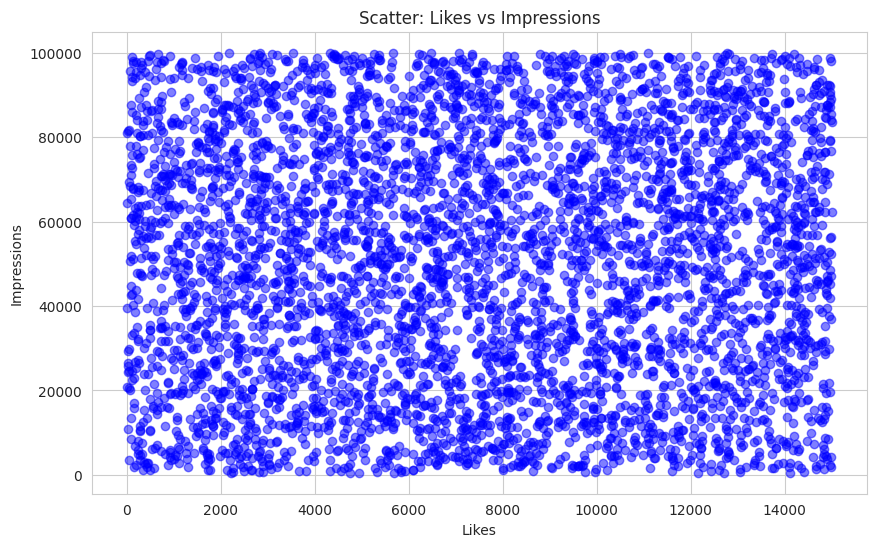

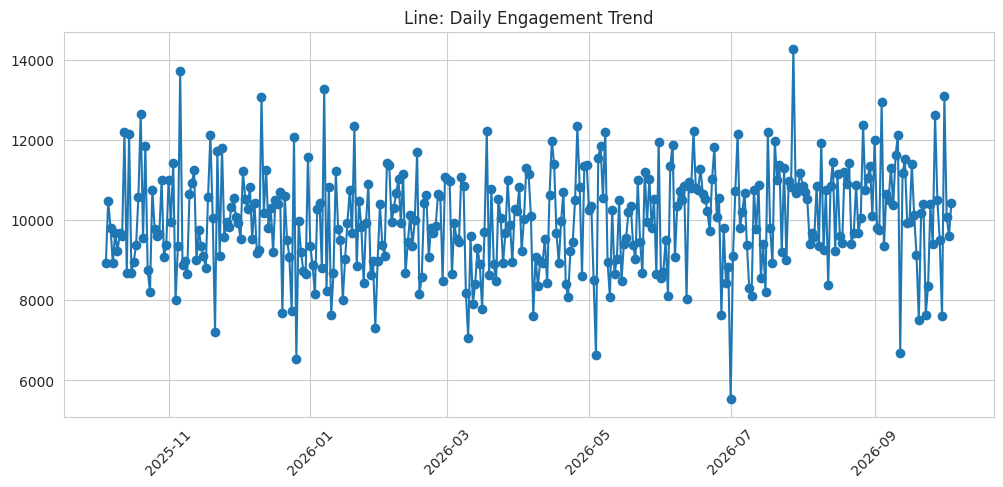

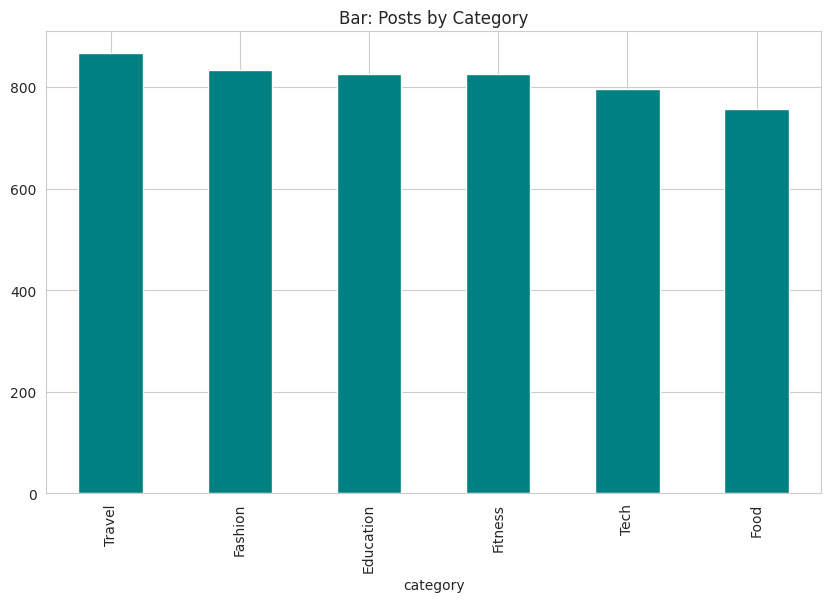

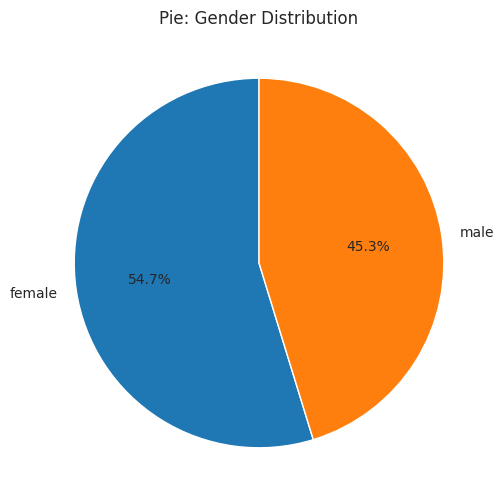

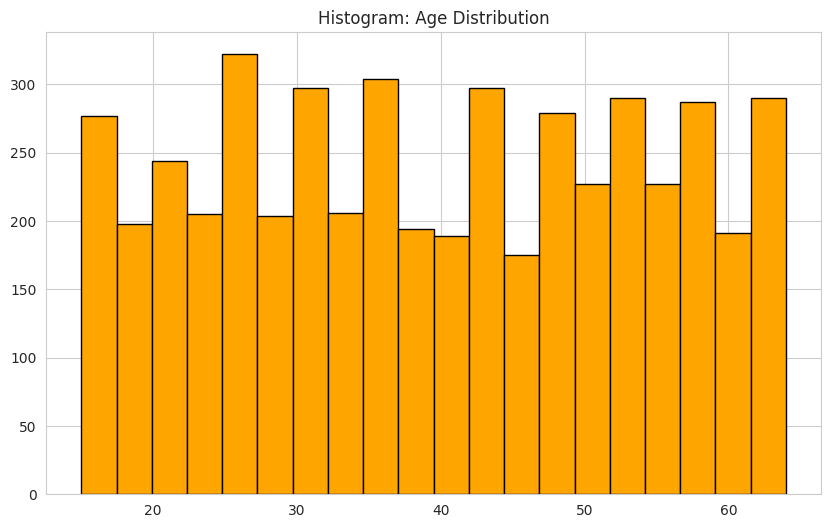

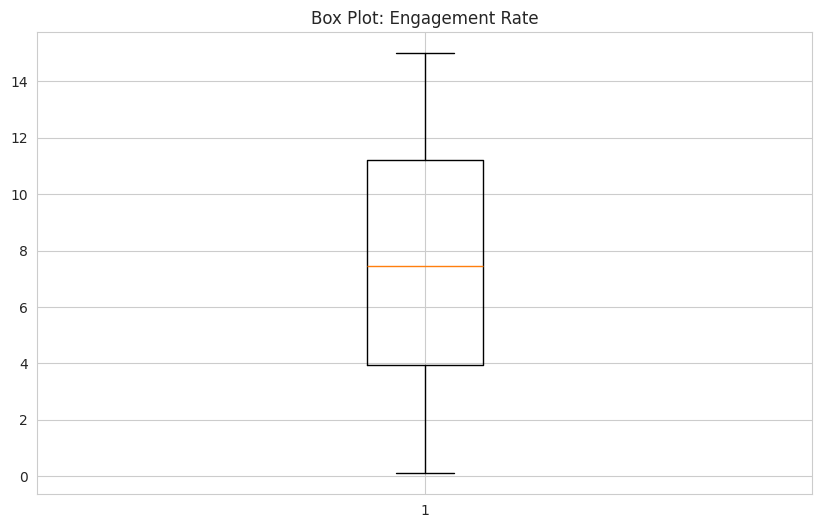

/tmp/ipykernel_4217/3007807956.py:219: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




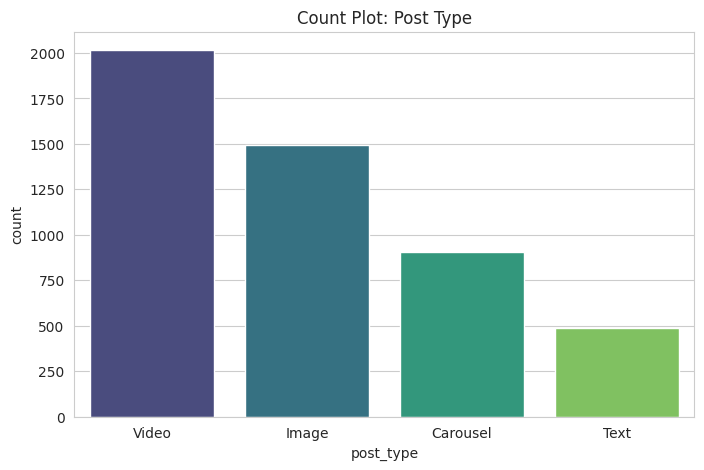

/tmp/ipykernel_4217/3007807956.py:226: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




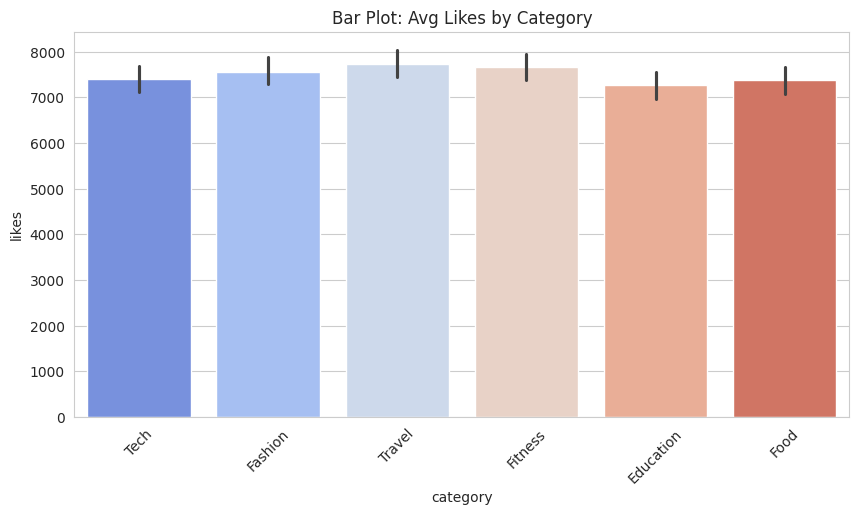

/tmp/ipykernel_4217/3007807956.py:233: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




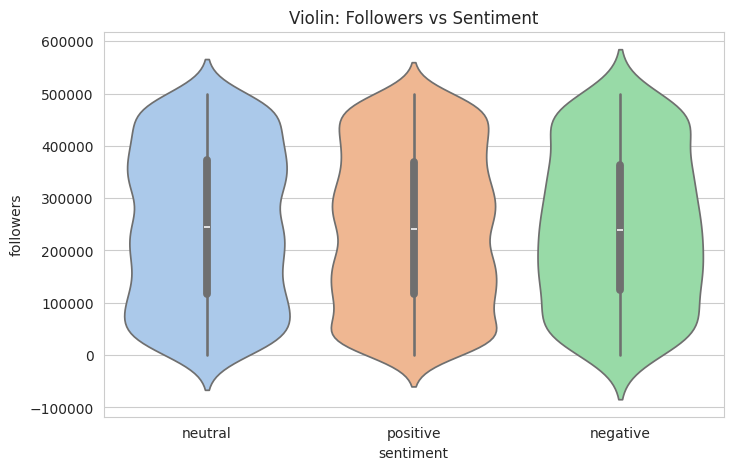

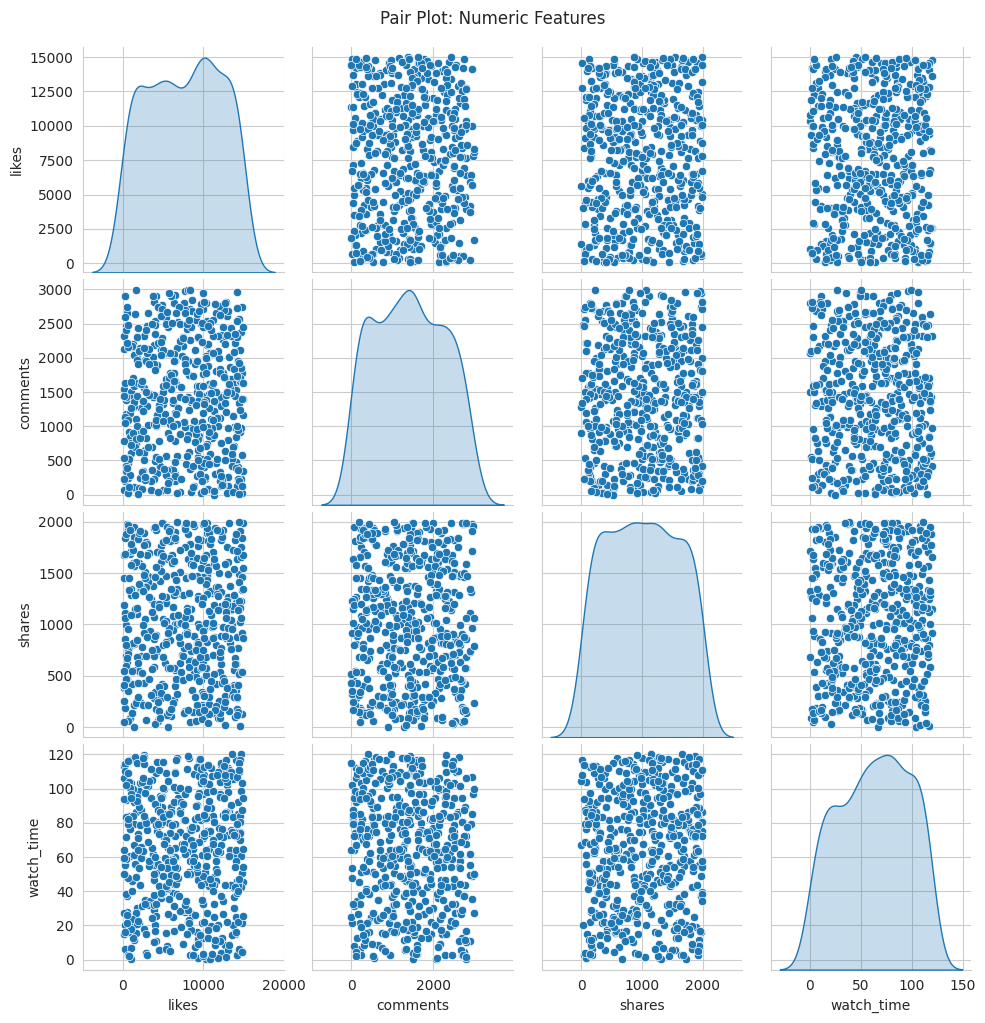

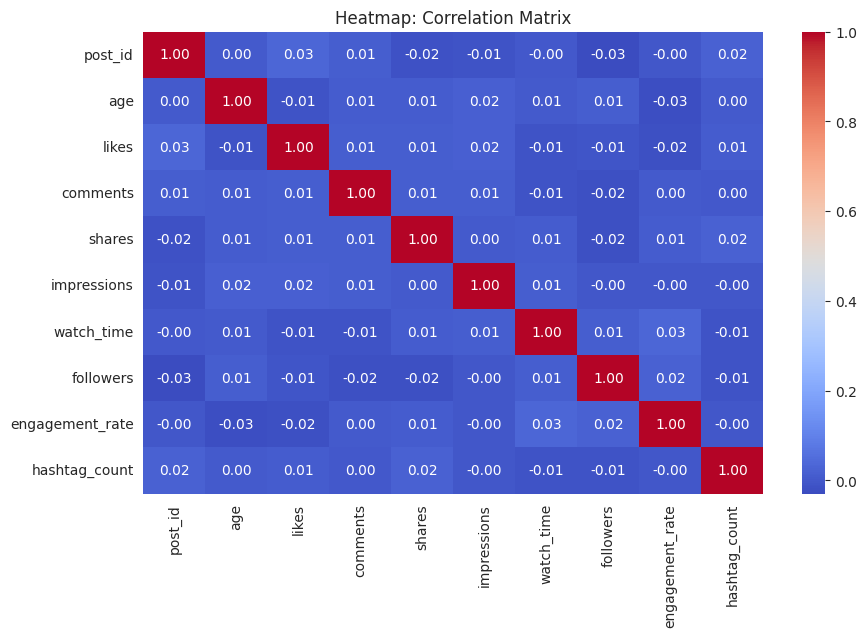

/tmp/ipykernel_4217/3007807956.py:251: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




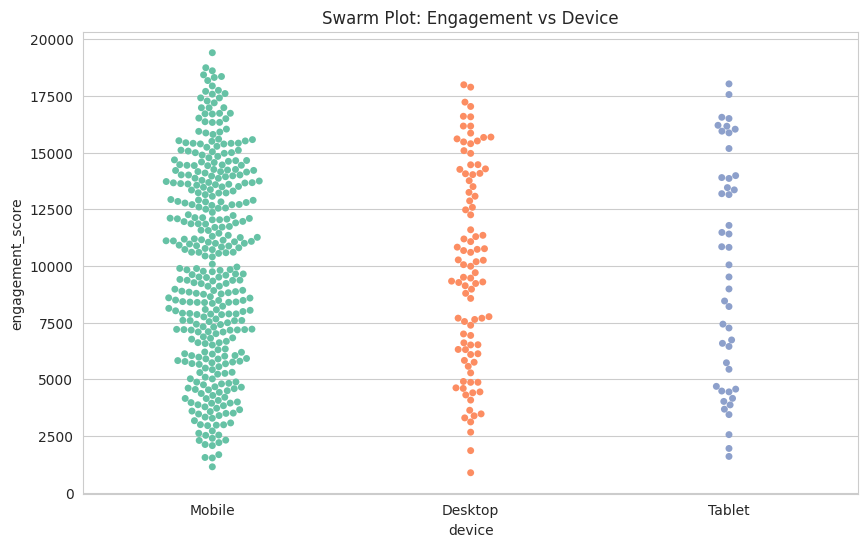


All Visualizations Completed!


In [7]:
# ============================================================
# Social Media Engagement Analytics - Module End 5
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)

# ❖ Task 1 — Data Import & Setup
df = pd.read_csv("social_media_engagement_5000.csv")
print(f"Shape: {df.shape}")
df.head()

# Check / Convert data types
print(df.dtypes)
print(df.info())

# Convert date columns to datetime - auto-detect date cols, excluding ID and numeric time columns
for col in df.columns:
    if 'date' in col.lower() and 'id' not in col.lower():
        try:
            df[col] = pd.to_datetime(df[col])
            print(f"Converted {col} to datetime")
        except:
            pass

# If you know exact column name: e.g., df['post_date'] = pd.to_datetime(df['post_date'])

# ❖ Task 2 — Data Cleaning

# 1. Cleaning Missing Data
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())
print(df.isna().sum())

# Handle numerical - median/mode, forward-fill
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Handle categorical - mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Forward / Backward fill for time-based
df = df.ffill()
df = df.bfill()

# 2. Duplicate Handling
print(f"\nDuplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

# 3. Data Formatting
# Standardize categories e.g., gender labels
if 'gender' in df.columns:
    df['gender'] = df['gender'].str.lower().str.strip()
    df['gender'] = df['gender'].replace({'m':'male','f':'female','mle':'male','femle':'female'})

if 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].str.lower().str.strip()

# Correct unrealistic values in likes, comments, shares (negative values)
for col in ['likes','comments','shares','impressions','watch_time','followers']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)
        df[col] = df[col].fillna(df[col].median())

# 4. Feature Cleaning
# Extract hashtag count
if 'hashtags' in df.columns:
    df['hashtag_count'] = df['hashtags'].astype(str).apply(lambda x: x.count('#'))
elif 'caption' in df.columns:
    df['hashtag_count'] = df['caption'].astype(str).str.count('#')
else:
    # if post_content exists
    for col in df.columns:
        if 'content' in col.lower() or 'text' in col.lower():
            df['hashtag_count'] = df[col].astype(str).str.count('#')

# Clean sentiment labels
if 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].str.lower()
    valid_sentiments = ['positive','negative','neutral']
    df = df[df['sentiment'].isin(valid_sentiments)]

print("\nAfter Cleaning:")
print(df.isnull().sum())

# ❖ Task 3 — Data Exploration using Pandas
print("\n========== TASK 3: EXPLORATION ==========")
print(df.head())
print(df.tail())
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(df.info())
print(df.dtypes)
print("\n--- Describe ---")
print(df.describe(include='all'))
print("\n--- Value Counts ---")
for col in ['post_type','category','country','gender','sentiment','device','platform']:
    if col in df.columns:
        print(f"\n{col} value_counts:\n{df[col].value_counts().head()}")
        print(f"Unique: {df[col].nunique()}, Values: {df[col].unique()[:5]}")

# Correlation matrix
print("\n--- Correlation Matrix ---")
numeric_df = df.select_dtypes(include=[np.number])
print(numeric_df.corr())

# Groupby summaries
if 'post_type' in df.columns and 'likes' in df.columns:
    print("\nAvg Likes by Post Type:\n", df.groupby('post_type')['likes'].mean())
if 'country' in df.columns and 'impressions' in df.columns:
    print("\nAvg Impressions by Country:\n", df.groupby('country')['impressions'].mean().sort_values(ascending=False))

# ❖ Task 4 — Data Wrangling
print("\n========== TASK 4: WRANGLING ==========")

# Create new fields
if all(c in df.columns for c in ['likes','comments','shares']):
    df['engagement_score'] = df['likes'] + df['comments'] + df['shares']
    # Alternative weighted score
    df['engagement_score_weighted'] = df['likes']*1 + df['comments']*2 + df['shares']*3

if 'likes' in df.columns:
    df['log_likes'] = np.log1p(df['likes'])

if 'engagement_score' in df.columns and 'impressions' in df.columns:
    df['engagement_rate_calc'] = (df['engagement_score'] / df['impressions'] * 100).round(2)

# Groupby summaries by post_type, country, sentiment
for group_col in ['post_type','country','sentiment','category']:
    if group_col in df.columns:
        print(f"\n--- Groupby {group_col} ---")
        print(df.groupby(group_col)[['likes','comments','shares','engagement_score']].mean().sort_values('likes', ascending=False).head())

# Merge/concat example (if you have to combine - demonstration)
# df_extra = df[['post_id','followers']].copy() # example
# df = pd.merge(df, df_extra, on='post_id', how='left') # not needed if single file

# ❖ Task 5 — Statistical Analysis
print("\n========== TASK 5: STATISTICAL ANALYSIS ==========")
target_cols = ['likes','comments','shares','watch_time','engagement_rate','followers']
for col in target_cols:
    if col in df.columns:
        print(f"\n--- {col.upper()} ---")
        print(f"Mean: {df[col].mean():.2f}")
        print(f"Median: {df[col].median():.2f}")
        print(f"Mode: {df[col].mode()[0]}")
        print(f"Std Dev: {df[col].std():.2f}")
        print(f"Variance: {df[col].var():.2f}")
        print(f"Min: {df[col].min()}, Max: {df[col].max()}")
        print(f"Percentiles (25%,50%,75%,90%):\n{df[col].quantile([0.25,0.5,0.75,0.9])}")
        print(f"Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurtosis():.2f}")

# ❖ Task 6 — Data Visualization (Min 8 Plots)

# Matplotlib
# 1. Scatter: likes vs impressions
plt.figure()
plt.scatter(df['likes'], df['impressions'], alpha=0.5, c='blue')
plt.title('Scatter: Likes vs Impressions')
plt.xlabel('Likes'); plt.ylabel('Impressions')
plt.show()

# 2. Line: daily engagement trend
if 'post_date' in df.columns or 'date' in df.columns:
    date_col = 'post_date' if 'post_date' in df.columns else [c for c in df.columns if 'date' in c.lower()][0]
    daily = df.groupby(df[date_col].dt.date)['engagement_score'].mean()
    plt.figure(figsize=(12,5))
    plt.plot(daily.index, daily.values, marker='o')
    plt.title('Line: Daily Engagement Trend')
    plt.xticks(rotation=45); plt.show()

# 3. Bar: posts by category
if 'category' in df.columns:
    plt.figure()
    df['category'].value_counts().plot(kind='bar', color='teal')
    plt.title('Bar: Posts by Category')
    plt.show()

# 4. Pie: gender distribution
if 'gender' in df.columns:
    plt.figure()
    df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title('Pie: Gender Distribution'); plt.ylabel('')
    plt.show()

# 5. Histogram: age
if 'age' in df.columns:
    plt.figure()
    plt.hist(df['age'], bins=20, color='orange', edgecolor='black')
    plt.title('Histogram: Age Distribution')
    plt.show()

# 6. Box: engagement rate
if 'engagement_rate' in df.columns:
    plt.figure()
    plt.boxplot(df['engagement_rate'].dropna())
    plt.title('Box Plot: Engagement Rate')
    plt.show()

# Seaborn
# 7. Count plot: post type
if 'post_type' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x='post_type', palette='viridis')
    plt.title('Count Plot: Post Type')
    plt.show()

# 8. Bar plot: avg likes by category
if 'category' in df.columns:
    plt.figure(figsize=(10,5))
    sns.barplot(data=df, x='category', y='likes', estimator=np.mean, palette='coolwarm')
    plt.title('Bar Plot: Avg Likes by Category'); plt.xticks(rotation=45)
    plt.show()

# 9. Violin: followers vs sentiment
if 'sentiment' in df.columns and 'followers' in df.columns:
    plt.figure(figsize=(8,5))
    sns.violinplot(data=df, x='sentiment', y='followers', palette='pastel')
    plt.title('Violin: Followers vs Sentiment')
    plt.show()

# 10. Pair plot: numeric features
sns.pairplot(df[['likes','comments','shares','watch_time']].sample(500), diag_kind='kde')
plt.suptitle('Pair Plot: Numeric Features', y=1.02)
plt.show()

# 11. Heatmap: correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap: Correlation Matrix')
plt.show()

# 12. Swarm plot: engagement vs device
if 'device' in df.columns and 'engagement_score' in df.columns:
    plt.figure(figsize=(10,6))
    sns.swarmplot(data=df.sample(500), x='device', y='engagement_score', palette='Set2')
    plt.title('Swarm Plot: Engagement vs Device')
    plt.show()

# Plotly Interactive
# 13. Interactive line/bar/bubble/scatter
if 'post_type' in df.columns:
    fig = px.bar(df.groupby('post_type')['likes'].mean().reset_index(), x='post_type', y='likes', title='Interactive: Avg Likes by Post Type')
    fig.show()

if 'likes' in df.columns and 'impressions' in df.columns:
    fig2 = px.scatter(df.sample(1000), x='likes', y='impressions', size='followers' if 'followers' in df.columns else None,
                      color='sentiment' if 'sentiment' in df.columns else None, hover_data=['post_type'] if 'post_type' in df.columns else None,
                      title='Interactive Bubble: Likes vs Impressions (size=followers)')
    fig2.show()

if 'post_date' in df.columns:
    daily_plotly = df.groupby(df['post_date'].dt.date)['engagement_score'].mean().reset_index()
    fig3 = px.line(daily_plotly, x='post_date', y='engagement_score', title='Interactive Daily Engagement Trend')
    fig3.show()

print("\nAll Visualizations Completed!")